In [1]:
# =============================================================================
# PHASE 4 — EXPLANATION ENGINE
# Macro-Market Regime Detection System
# =============================================================================
# Builds the "why the model thinks this" layer for the dashboard:
#   1. Feature contribution scorer — ranks which features most strongly
#      characterise the current regime vs. the historical average
#   2. Narrative generator — turns the top features into a plain-English
#      sentence the dashboard's explanation panel will display
#   3. Regime statistics table — avg duration, frequency, returns/vol per regime
#   4. Classify new data — loads saved models and labels a fresh observation
#
# Input:  data/processed/us_regime_labels.parquet
#         data/processed/us_features_daily.parquet
#         data/processed/us_state_means.parquet
#         models/  (hmm_model.pkl, pca_model.pkl, state_labels.pkl, etc.)
#
# Output: data/processed/us_regime_stats.parquet  (regime statistics table)
#         data/processed/us_feature_contributions.parquet
#         models/feature_meta.pkl  (feature display names + units for dashboard)
# =============================================================================


In [2]:
# -----------------------------------------------------------------------------
# CELL 1 — Imports & load Phase 3 outputs
# -----------------------------------------------------------------------------
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROCESSED_DIR = "data/processed"
MODEL_DIR     = "models"

# ── Load regime labels and raw features
regime_df = pd.read_parquet(f"{PROCESSED_DIR}/us_regime_labels.parquet")
feat_raw  = pd.read_parquet(f"{PROCESSED_DIR}/us_features_daily.parquet")
feat_raw  = feat_raw[feat_raw.index >= "2003-01-01"].dropna()

# ── Load fitted models and metadata
with open(f"{MODEL_DIR}/hmm_model.pkl",      "rb") as f: hmm_model    = pickle.load(f)
with open(f"{MODEL_DIR}/pca_model.pkl",      "rb") as f: pca_model    = pickle.load(f)
with open(f"{MODEL_DIR}/state_labels.pkl",   "rb") as f: STATE_LABELS = pickle.load(f)
with open(f"{MODEL_DIR}/regime_colors.pkl",  "rb") as f: REGIME_COLORS= pickle.load(f)
with open(f"{MODEL_DIR}/state_means_df.pkl", "rb") as f: state_means_df = pickle.load(f)

# Align index
feat_raw = feat_raw.reindex(regime_df.index)

print("Loaded regime labels:", regime_df.shape)
print("Loaded feature matrix:", feat_raw.shape)
print("Regimes:", regime_df["regime"].value_counts().to_dict())


Loaded regime labels: (5885, 4)
Loaded feature matrix: (5885, 16)
Regimes: {'Risk-Off': 2412, 'Risk-On': 1567, 'Inflation-Driven': 1045, 'High-Volatility': 861}


In [3]:
# -----------------------------------------------------------------------------
# CELL 2 — Feature metadata (display names and units for the dashboard)
# -----------------------------------------------------------------------------
# Maps internal column names to human-readable labels and units.
# This is what the explanation panel prints — "VIX at 28.3" not "vix_level=28.3".

FEATURE_META = {
    "sp500_ret":              {"label": "S&P 500 daily return",        "unit": "%",    "scale": 100,  "direction": "higher = bullish"},
    "realized_vol_20d":       {"label": "Realized volatility (20d)",   "unit": "%",    "scale": 100,  "direction": "higher = more volatile"},
    "realized_vol_60d":       {"label": "Realized volatility (60d)",   "unit": "%",    "scale": 100,  "direction": "higher = more volatile"},
    "vix_level":              {"label": "VIX (fear index)",            "unit": "",     "scale": 1,    "direction": "higher = more fear"},
    "vix_change_20d":         {"label": "VIX change (20d)",            "unit": "pts",  "scale": 1,    "direction": "rising = increasing fear"},
    "sp500_drawdown":         {"label": "S&P 500 drawdown",            "unit": "%",    "scale": 100,  "direction": "more negative = deeper drawdown"},
    "garch_vol":              {"label": "GARCH conditional vol",       "unit": "%",    "scale": 100,  "direction": "higher = more volatile"},
    "curve_slope_10y2y":      {"label": "Yield curve slope (10Y–2Y)",  "unit": "pp",   "scale": 1,    "direction": "negative = inverted (recession signal)"},
    "fed_funds_level":        {"label": "Fed Funds Rate",              "unit": "%",    "scale": 1,    "direction": "higher = tighter policy"},
    "fed_funds_change_60d":   {"label": "Fed Funds change (60d)",      "unit": "pp",   "scale": 1,    "direction": "positive = hiking cycle"},
    "credit_spread":          {"label": "Credit spread (Baa–10Y)",     "unit": "pp",   "scale": 1,    "direction": "wider = more risk aversion"},
    "credit_spread_change_20d":{"label": "Credit spread change (20d)", "unit": "pp",   "scale": 1,    "direction": "positive = deteriorating conditions"},
    "breakeven_inflation":    {"label": "5Y breakeven inflation",      "unit": "%",    "scale": 1,    "direction": "higher = higher inflation expectations"},
    "cpi_yoy":                {"label": "CPI inflation (YoY)",         "unit": "%",    "scale": 1,    "direction": "higher = more inflationary"},
    "indpro_yoy":             {"label": "Industrial production (YoY)", "unit": "%",    "scale": 1,    "direction": "positive = economic expansion"},
    "philly_fed":             {"label": "Philly Fed Manufacturing",    "unit": "",     "scale": 1,    "direction": "positive = manufacturing expansion"},
}

print(f"Feature metadata defined for {len(FEATURE_META)} features")


Feature metadata defined for 16 features


In [4]:
# -----------------------------------------------------------------------------
# CELL 3 — Feature contribution scorer
# -----------------------------------------------------------------------------
# For any given observation (or the current day), score how much each feature
# contributes to the assigned regime. Method:
#   z-score each feature relative to its full-sample mean and std, then
#   weight by the feature's deviation from the current regime's historical mean.
#
# Output: a Series of (feature → contribution score), sorted by magnitude.
# Positive = feature is elevated vs history; negative = depressed vs history.
# The top 3 by absolute value become the explanation text.

# Global stats (used to contextualise each feature value for the user)
feat_mean = feat_raw.mean()
feat_std  = feat_raw.std()

def score_contributions(obs: pd.Series, regime_label: str) -> pd.Series:
    """
    Score each feature's contribution to the assigned regime.

    Parameters
    ----------
    obs          : pd.Series  — one row of feat_raw (raw, unscaled values)
    regime_label : str        — the assigned regime label (e.g. 'Risk-On')

    Returns
    -------
    pd.Series sorted by absolute contribution (descending).
    Positive = this feature is elevated vs its long-run mean and consistent
               with the regime; negative = depressed.
    """
    # State means for the assigned regime
    state_id = {v: k for k, v in STATE_LABELS.items()}[regime_label]
    regime_means = state_means_df.loc[f"State {state_id}"]

    scores = {}
    for col in feat_raw.columns:
        if col not in obs.index or pd.isna(obs[col]):
            continue
        # How far is today's value from the full-sample mean, in std units?
        z_today = (obs[col] - feat_mean[col]) / (feat_std[col] + 1e-9)
        # How much does this regime typically deviate from the full-sample mean?
        z_regime = (regime_means[col] - feat_mean[col]) / (feat_std[col] + 1e-9)
        # Contribution = alignment between today's deviation and regime's typical deviation
        scores[col] = z_today * np.sign(z_regime) if abs(z_regime) > 0.1 else 0.0

    return pd.Series(scores).sort_values(key=abs, ascending=False)


In [5]:
# -----------------------------------------------------------------------------
# CELL 4 — Narrative generator
# -----------------------------------------------------------------------------
# Turns the top feature contributions into a one-paragraph plain-English
# explanation. Used directly in the dashboard's "Why the model thinks this"
# panel.

def format_feature_value(col: str, val: float) -> str:
    """Format a raw feature value with its label and unit for display."""
    meta  = FEATURE_META.get(col, {"label": col, "unit": "", "scale": 1})
    label = meta["label"]
    unit  = meta["unit"]
    scaled = val * meta["scale"]
    if abs(scaled) >= 10:
        return f"{label} at {scaled:.1f}{(' ' + unit) if unit else ''}"
    else:
        return f"{label} at {scaled:.2f}{(' ' + unit) if unit else ''}"

def describe_direction(col: str, val: float) -> str:
    """Return a short directional descriptor ('elevated', 'depressed', etc.)"""
    z = (val - feat_mean[col]) / (feat_std[col] + 1e-9)
    if z > 1.5:   return "well above historical average"
    if z > 0.5:   return "above historical average"
    if z < -1.5:  return "well below historical average"
    if z < -0.5:  return "below historical average"
    return "near historical average"

REGIME_INTROS = {
    "Risk-On":          "Markets are in a Risk-On regime.",
    "Risk-Off":         "Markets are in a Risk-Off / slow-growth regime.",
    "High-Volatility":  "Markets are in a High-Volatility / Crisis regime.",
    "Inflation-Driven": "Markets are in an Inflation-Driven regime.",
}

PORTFOLIO_TILTS = {
    # These are regime-level, historically motivated tilt suggestions based on
    # how asset classes have performed in each macro regime on average.
    # They are NOT real-time tactical recommendations and do NOT account for
    # valuations, individual risk tolerance, or current positioning.
    # Always append the disclaimer below when displaying in the dashboard.
    "Risk-On":          "Portfolio tilt suggestion: favour equities, cyclicals, and credit. (Regime-based signal — not investment advice.)",
    "Risk-Off":         "Portfolio tilt suggestion: reduce equity exposure, favour quality bonds and short duration. (Regime-based signal — not investment advice.)",
    "High-Volatility":  "Portfolio tilt suggestion: defensive assets, cash equivalents, and tail-risk hedges. (Regime-based signal — not investment advice.)",
    "Inflation-Driven": "Portfolio tilt suggestion: inflation-linked bonds, commodities, and real assets. (Regime-based signal — not investment advice.)",
}

def generate_explanation(obs: pd.Series, regime_label: str,
                         confidence: float, top_n: int = 3) -> str:
    """
    Generate a plain-English explanation of why the model assigned this regime.

    Parameters
    ----------
    obs          : pd.Series  — one row of feat_raw
    regime_label : str        — assigned regime label
    confidence   : float      — HMM posterior probability (0–1)
    top_n        : int        — number of top features to mention

    Returns
    -------
    str  — multi-sentence explanation ready for dashboard display
    """
    contribs = score_contributions(obs, regime_label)
    top_features = contribs.head(top_n).index.tolist()

    intro    = REGIME_INTROS[regime_label]
    conf_str = f"Model confidence: {confidence:.0%}."

    # Build the "driven by" sentence
    feature_phrases = []
    for col in top_features:
        val  = obs[col]
        desc = describe_direction(col, val)
        feature_phrases.append(f"{FEATURE_META.get(col, {}).get('label', col)} ({desc})")

    if len(feature_phrases) == 1:
        driven_by = f"This is primarily driven by {feature_phrases[0]}."
    elif len(feature_phrases) == 2:
        driven_by = f"This is driven by {feature_phrases[0]} and {feature_phrases[1]}."
    else:
        driven_by = (f"This is driven by {feature_phrases[0]}, "
                     f"{feature_phrases[1]}, and {feature_phrases[2]}.")

    tilt = PORTFOLIO_TILTS[regime_label]

    return f"{intro} {conf_str} {driven_by} {tilt}"


In [6]:
# -----------------------------------------------------------------------------
# CELL 5 — Test the explanation engine on the most recent day
# -----------------------------------------------------------------------------
# IMPORTANT — two ways to get the current regime, and they can differ:
#
#   1. regime_df.iloc[-1]["regime"]  ← USE THIS for the dashboard's current-
#      regime display. This comes from the Viterbi algorithm applied to the
#      full historical sequence in Phase 3 — it is globally optimal because
#      it uses the entire sequence context (past transitions, future smoothing)
#      to assign each day's state.
#
#   2. classify_new_observation() in Cell 8  ← USE THIS only for classifying
#      genuinely new data that wasn't in the Phase 3 training window (e.g. a
#      new trading day after you last re-ran Phase 3). It runs a single-step
#      forward pass without sequence context, so it can differ from the Viterbi
#      label on the same date. The difference is a known property of HMMs, not
#      a bug — they answer different questions.
#
# Rule of thumb for the dashboard: always use regime_df for historical dates;
# only use classify_new_observation() for dates beyond the last Viterbi decode.

latest_date    = regime_df.index[-1]
latest_obs     = feat_raw.loc[latest_date]
latest_regime  = regime_df.loc[latest_date, "regime"]
latest_conf    = regime_df.loc[latest_date, "confidence"]

explanation = generate_explanation(latest_obs, latest_regime, latest_conf)

print(f"Latest date   : {latest_date.date()}")
print(f"Regime        : {latest_regime}")
print(f"Confidence    : {latest_conf:.1%}")
print()
print("── Explanation ──────────────────────────────────────────────────────")
print(explanation)
print()

# Show the full ranked contribution table for the latest day
contribs = score_contributions(latest_obs, latest_regime)
print("── Feature contributions (sorted by absolute impact) ────────────────")
print(f"{'Feature':<30} {'Contribution':>14}  {'Raw value':>12}")
print("-" * 60)
for col, score in contribs.items():
    raw_val = latest_obs[col]
    meta    = FEATURE_META.get(col, {"scale": 1, "unit": ""})
    display = raw_val * meta["scale"]
    unit    = meta["unit"]
    print(f"{col:<30} {score:>14.3f}  {display:>10.3f} {unit}")


Latest date   : 2026-05-22
Regime        : Risk-On
Confidence    : 100.0%

── Explanation ──────────────────────────────────────────────────────
Markets are in a Risk-On regime. Model confidence: 100%. This is driven by Credit spread (Baa–10Y) (below historical average), 5Y breakeven inflation (above historical average), and Fed Funds Rate (above historical average). Portfolio tilt suggestion: favour equities, cyclicals, and credit. (Regime-based signal — not investment advice.)

── Feature contributions (sorted by absolute impact) ────────────────
Feature                          Contribution     Raw value
------------------------------------------------------------
credit_spread                           1.114       1.570 pp
breakeven_inflation                     1.019       2.540 %
fed_funds_level                         0.975       3.630 %
sp500_drawdown                          0.924      -0.370 %
cpi_yoy                                 0.873       4.167 %
curve_slope_10y2y      

In [7]:
# -----------------------------------------------------------------------------
# CELL 6 — Test on a known historical date: March 2020 (COVID crash)
# -----------------------------------------------------------------------------
# A well-known stress event — the model should label it High-Volatility
# with strong feature contributions from VIX, realized vol, and drawdown.

test_dates = {
    "COVID crash (Mar 2020)":       "2020-03-16",
    "GFC peak stress (Oct 2008)":   "2008-10-15",
    "2022 inflation peak (Jun 2022)":"2022-06-13",
    "Bull market (Jan 2018)":        "2018-01-26",
}

for event, date_str in test_dates.items():
    try:
        date = pd.Timestamp(date_str)
        # Find the nearest trading day if the exact date isn't in the index
        idx  = regime_df.index.get_indexer([date], method="nearest")[0]
        date = regime_df.index[idx]
        obs  = feat_raw.loc[date]
        reg  = regime_df.loc[date, "regime"]
        conf = regime_df.loc[date, "confidence"]
        exp  = generate_explanation(obs, reg, conf, top_n=2)
        print(f"── {event}")
        print(f"   Date: {date.date()}  |  Regime: {reg}  |  Confidence: {conf:.0%}")
        print(f"   {exp}")
        print()
    except Exception as e:
        print(f"── {event}: skipped ({e})")


── COVID crash (Mar 2020)
   Date: 2020-03-16  |  Regime: High-Volatility  |  Confidence: 100%
   Markets are in a High-Volatility / Crisis regime. Model confidence: 100%. This is driven by VIX change (20d) (well above historical average) and VIX (fear index) (well above historical average). Portfolio tilt suggestion: defensive assets, cash equivalents, and tail-risk hedges. (Regime-based signal — not investment advice.)

── GFC peak stress (Oct 2008)
   Date: 2008-10-15  |  Regime: High-Volatility  |  Confidence: 100%
   Markets are in a High-Volatility / Crisis regime. Model confidence: 100%. This is driven by GARCH conditional vol (well above historical average) and Realized volatility (20d) (well above historical average). Portfolio tilt suggestion: defensive assets, cash equivalents, and tail-risk hedges. (Regime-based signal — not investment advice.)

── 2022 inflation peak (Jun 2022)
   Date: 2022-06-13  |  Regime: Inflation-Driven  |  Confidence: 100%
   Markets are in an Infla

In [8]:
# -----------------------------------------------------------------------------
# CELL 7 — Regime statistics table
# -----------------------------------------------------------------------------
# For each regime: count of days, % of total, average duration of continuous
# episodes, and mean/std of key market metrics. Used in the dashboard's
# "Regime Statistics" panel.

def regime_stats(regime_df: pd.DataFrame, feat_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for regime in regime_df["regime"].unique():
        mask = regime_df["regime"] == regime
        days = mask.sum()

        # Average episode duration: count consecutive runs
        episodes   = (regime_df["regime"] != regime_df["regime"].shift()).cumsum()
        ep_lengths = regime_df[mask].groupby(episodes[mask]).size()
        avg_dur    = ep_lengths.mean()
        n_episodes = len(ep_lengths)

        # Key metric means within this regime
        sub = feat_raw[mask]
        rows.append({
            "Regime":            regime,
            "Days":              int(days),
            "% of History":      f"{days/len(regime_df):.1%}",
            "Episodes":          int(n_episodes),
            "Avg Duration (days)": f"{avg_dur:.0f}",
            "Avg VIX":           f"{sub['vix_level'].mean():.1f}",
            "Avg Realized Vol":  f"{sub['realized_vol_20d'].mean()*100:.1f}%",
            "Avg CPI YoY":       f"{sub['cpi_yoy'].mean():.1f}%",
            "Avg Credit Spread": f"{sub['credit_spread'].mean():.2f}pp",
            "Avg Philly Fed":    f"{sub['philly_fed'].mean():.1f}",
        })

    stats_df = pd.DataFrame(rows).set_index("Regime")
    return stats_df

stats = regime_stats(regime_df, feat_raw)
print("Regime Statistics Table:")
print(stats.to_string())


Regime Statistics Table:
                  Days % of History  Episodes Avg Duration (days) Avg VIX Avg Realized Vol Avg CPI YoY Avg Credit Spread Avg Philly Fed
Regime                                                                                                                                 
High-Volatility    861        14.6%        12                  72    32.5            32.2%        1.9%            3.55pp          -10.6
Risk-Off          2412        41.0%         9                 268    16.8            12.1%        1.7%            2.61pp           13.9
Risk-On           1567        26.6%        12                 131    14.5            10.5%        3.4%            1.73pp           11.3
Inflation-Driven  1045        17.8%        13                  80    20.4            17.5%        4.1%            2.05pp            4.4


In [9]:
# -----------------------------------------------------------------------------
# CELL 8 — Classify a new observation (real-time inference function)
# -----------------------------------------------------------------------------
# This is what the dashboard calls when a user hits "Refresh" — it loads the
# latest feature values, runs them through PCA → HMM, and returns the regime,
# confidence, explanation, and contribution scores.

def classify_new_observation(raw_obs: pd.Series) -> dict:
    """
    Classify a single new observation into a regime using a forward pass.

    USE THIS ONLY for dates beyond the last Viterbi decode (i.e. genuinely new
    data not yet in regime_df). For any date already in regime_df, use
    regime_df.loc[date, "regime"] instead — the Viterbi sequence is globally
    optimal and will give a different (more reliable) answer than this function
    on the same date, because Viterbi uses full sequence context while this
    function only sees a single observation.

    Parameters
    ----------
    raw_obs : pd.Series  — feature values with the same column names as feat_raw
                           (raw, unscaled — the function handles z-scoring)

    Returns
    -------
    dict with keys: regime, state_id, confidence, all_probs, explanation,
                    contributions
    """
    # Z-score using the training distribution
    obs_z = (raw_obs - feat_mean) / (feat_std + 1e-9)

    # Apply PCA transform
    obs_pca = pca_model.transform(obs_z.values.reshape(1, -1))

    # HMM posterior probabilities
    log_probs = hmm_model.score_samples(obs_pca)
    probs     = hmm_model.predict_proba(obs_pca)[0]
    state_id  = int(np.argmax(probs))
    regime    = STATE_LABELS[state_id]
    confidence= float(probs[state_id])

    # Explanation
    explanation = generate_explanation(raw_obs, regime, confidence)

    # Contributions
    contribs = score_contributions(raw_obs, regime)

    return {
        "regime":        regime,
        "state_id":      state_id,
        "confidence":    confidence,
        "all_probs":     {STATE_LABELS[i]: float(p) for i, p in enumerate(probs)},
        "explanation":   explanation,
        "contributions": contribs,
    }

# Test on the latest day — and show the Viterbi vs forward-pass comparison
result = classify_new_observation(feat_raw.iloc[-1])
viterbi_regime = regime_df.iloc[-1]["regime"]

print("classify_new_observation() on latest data (single forward pass):")
print(f"  Regime     : {result['regime']}")
print(f"  Confidence : {result['confidence']:.1%}")
print(f"  All probs  : { {k: f'{v:.1%}' for k, v in result['all_probs'].items()} }")
print()
print(f"Viterbi regime for same date (from regime_df): {viterbi_regime}")
if result['regime'] != viterbi_regime:
    print("  ↑ These differ — expected. Viterbi uses full sequence context;")
    print("    forward pass sees only one observation. Use Viterbi for the dashboard.")
else:
    print("  ↑ Both agree on this date.")


classify_new_observation() on latest data (single forward pass):
  Regime     : High-Volatility
  Confidence : 100.0%
  All probs  : {'Inflation-Driven': '0.0%', 'Risk-Off': '0.0%', 'Risk-On': '0.0%', 'High-Volatility': '100.0%'}

Viterbi regime for same date (from regime_df): Risk-On
  ↑ These differ — expected. Viterbi uses full sequence context;
    forward pass sees only one observation. Use Viterbi for the dashboard.


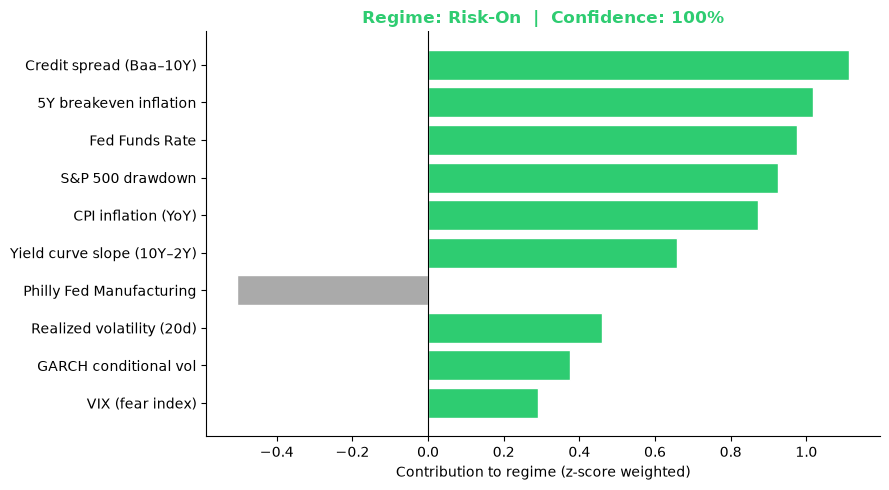

In [10]:
# -----------------------------------------------------------------------------
# CELL 9 — Feature contribution chart (dashboard-ready)
# -----------------------------------------------------------------------------
# Horizontal bar chart of feature contributions for the current regime.
# This becomes the "explanation panel" visual in the dashboard.

def plot_contributions(obs: pd.Series, regime_label: str,
                       confidence: float, top_n: int = 10, save_path: str = None):
    contribs = score_contributions(obs, regime_label).head(top_n)
    labels   = [FEATURE_META.get(c, {"label": c})["label"] for c in contribs.index]
    values   = contribs.values
    colors   = [REGIME_COLORS[regime_label] if v > 0 else "#aaaaaa" for v in values]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Contribution to regime (z-score weighted)")
    ax.set_title(
        f"Regime: {regime_label}  |  Confidence: {confidence:.0%}",
        fontweight="bold", color=REGIME_COLORS[regime_label]
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=130)
    plt.show()

plot_contributions(
    obs           = feat_raw.iloc[-1],
    regime_label  = regime_df.iloc[-1]["regime"],
    confidence    = regime_df.iloc[-1]["confidence"],
    save_path     = f"{PROCESSED_DIR}/explanation_panel_latest.png"
)


In [11]:
# -----------------------------------------------------------------------------
# CELL 10 — Save Phase 4 outputs
# -----------------------------------------------------------------------------
# Regime statistics table
stats.to_parquet(f"{PROCESSED_DIR}/us_regime_stats.parquet")
stats.to_csv(f"{PROCESSED_DIR}/us_regime_stats.csv")

# Pre-computed feature contributions for every day (for dashboard timeline)
all_contribs = {}
for date, row in feat_raw.iterrows():
    reg = regime_df.loc[date, "regime"]
    all_contribs[date] = score_contributions(row, reg)

contribs_df = pd.DataFrame(all_contribs).T
contribs_df.to_parquet(f"{PROCESSED_DIR}/us_feature_contributions.parquet")

# Feature metadata and inference functions
with open(f"{MODEL_DIR}/feature_meta.pkl",     "wb") as f: pickle.dump(FEATURE_META,     f)
with open(f"{MODEL_DIR}/feat_mean.pkl",        "wb") as f: pickle.dump(feat_mean,        f)
with open(f"{MODEL_DIR}/feat_std.pkl",         "wb") as f: pickle.dump(feat_std,         f)
with open(f"{MODEL_DIR}/regime_intros.pkl",    "wb") as f: pickle.dump(REGIME_INTROS,    f)
with open(f"{MODEL_DIR}/portfolio_tilts.pkl",  "wb") as f: pickle.dump(PORTFOLIO_TILTS,  f)

print("Saved:")
print(f"  Regime stats        : {PROCESSED_DIR}/us_regime_stats.parquet")
print(f"  Feature contribs    : {PROCESSED_DIR}/us_feature_contributions.parquet")
print(f"  Feature metadata    : {MODEL_DIR}/feature_meta.pkl")
print(f"  Inference inputs    : feat_mean.pkl, feat_std.pkl")
print()
print("Phase 4 complete — ready for Phase 5 (Streamlit dashboard).")


Saved:
  Regime stats        : data/processed/us_regime_stats.parquet
  Feature contribs    : data/processed/us_feature_contributions.parquet
  Feature metadata    : models/feature_meta.pkl
  Inference inputs    : feat_mean.pkl, feat_std.pkl

Phase 4 complete — ready for Phase 5 (Streamlit dashboard).
